# Blackbox-LSTM GR — Local Eval (learned-frontend ablation)

Evaluates models trained by [`train_lstm_blackbox_gr.ipynb`](train_lstm_blackbox_gr.ipynb)
(`model_type == "blackbox_gr_lstm_film"`) — the **ablation twin** of the detector run
([`eval_lstm_detector_gr.ipynb`](eval_lstm_detector_gr.ipynb)). Everything downstream of the
frontend is identical to the detector recipe (LSTM(8→32) → polynomial FiLM (knobs) + GLU →
direct dB head, same `DetectorGRSystem` loss, same split policy, same 3 s crop training), so
any metric difference between the two evals is attributable to the frontend alone.

Model traits mirrored from training:

- **Architecture**: `BlackboxGRLSTM` — learned Conv frame-encoder
  (`Conv1d(1→enc, kernel=256, stride=256)`, no squaring) → dilated causal temporal Conv
  stack (RF ≈ 255 frames ≈ 1.49 s) → 1×1 proj to the detector-bank width (8 ch) →
  identical LSTM → FiLM+GLU → dB head. **Timbre-capable** by construction, where the
  detector bank is timbre-blind (rectify → smooth → dB).
- **Conditioning**: normalised param vector per setting (`splits.normalize_setting_params`,
  [`NORMALISATION.md`](NORMALISATION.md)) through the FiLM+GLU layer. Guards assert
  `gr_range_db` / `param_ranges` match local `gr_target.py` / `splits.py`.
- **Split policy**: the external `test_ground_truth/` pairs are the ONLY held-out test set,
  excluded from train/val by pair key. Cell ── 2 **asserts** the run's manifest is disjoint
  from `test_ground_truth/` — a contaminated run cannot be scored here.
- **Stateless inference**: no module-held state — cold start = zeros = silence; whole-song
  streaming carries explicit `(lstm_state, frame_context)` and is exact vs a single full
  forward (the frame encoder is hop-aligned, so no input-sample tail is needed).
- **Metrics**: the canonical 9-column engine after **reconstruction** `dry × 10^(GR_dB/20)`,
  scored on the **validation split** (── 7) and the held-out **test set** (── 8).
- **Headline number (── 9)**: the **val→test GR MAE gap**, side-by-side with the detector
  twin. The predecessor bins model (learned raw-waveform frontend) showed
  **0.267 → 0.554 dB**, diagnosed as song timbre leaking into the GR estimate. If the
  blackbox reproduces a gap the detector doesn't, the structural frontend is justified
  empirically; if it matches the detector, the prior is unnecessary.

> Requirements: `uv sync` at repo root. Run after the Colab run dir has synced to Drive.


In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────

import gc, glob, json, os, sys, types, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore", category=UserWarning)

# stub `rational` so the optional nablafx verification import can't drag in broken wheels
rational = types.ModuleType("rational")
rational.torch = types.ModuleType("rational.torch")
rational.torch.Rational = type("Rational", (), {})
sys.modules["rational"], sys.modules["rational.torch"] = rational, rational.torch

sys.path.insert(0, str(Path.cwd().parent / "03_initial_GR_pred"))  # shared eval helpers

from src.dsp_torch import RMS_WINDOW, gain_reduction_db
from gr_target import GR_DB_MIN, GR_DB_MAX
from model_blackbox_gr import BlackboxGRLSTM
from splits import DIFFSSL_PARAM_RANGES, SplitManifest, normalize_setting_params
from eval_helpers import (
    _checkpoint_sort_key, _db_to_amplitude, _find_hparams_json, _pair_num_frames,
    _read_dry_wet_segment, _weighted_average_metric_rows, latest_best_checkpoint,
    list_runs, plot_loss_curves, wet_dir_for_setting,
)

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs"
SAMPLE_RATE = 44100
DEVICE = "cpu"

print(f"torch {torch.__version__}  |  device: {DEVICE}")
print(f"GR range: [{GR_DB_MIN}, {GR_DB_MAX}] dB")

torch 2.10.0  |  device: cpu
GR range: [-30.0, 5.0] dB


In [2]:
# ── 1. List available Blackbox-LSTM GR runs ──────────────────────────

MODEL_TYPE = "blackbox_gr_lstm_film"

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, f"No runs in {RUNS_DIR}"
available_models_df = runs_df[runs_df["type"] == MODEL_TYPE].copy()
assert not available_models_df.empty, (
    f"No '{MODEL_TYPE}' runs in {RUNS_DIR} — train with train_lstm_blackbox_gr.ipynb first."
)

display_cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available Blackbox-LSTM GR runs: {len(available_models_df)}")
display(available_models_df[display_cols])


Available Blackbox-LSTM GR runs: 1


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
35,lstm_gr_20260705_125142_lstm_blackbox_gr_film,blackbox_gr_lstm_film,150.0,0.104465,4,best-081-41000.ckpt,2026-07-05 13:17:16.165528297


In [3]:
# ── 2. Select run, checkpoint, split manifest + external test set ────

# Leave as None to auto-pick the most recently modified matching run.
SELECTED_RUN_NAME: str | None = None

if not SELECTED_RUN_NAME:
    selected_run = available_models_df.iloc[-1]   # list_runs sorts by mtime asc
else:
    matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
    assert len(matches) == 1, f"Run not found: {SELECTED_RUN_NAME}"
    selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

with open(HPARAMS_PATH) as f:
    HP = json.load(f)
SPLIT = SplitManifest.load(os.path.join(RUN_DIR, "split_manifest.json"))

# normalisation guards — see NORMALISATION.md
assert tuple(HP["gr_range_db"]) == (GR_DB_MIN, GR_DB_MAX), HP["gr_range_db"]
assert {k: tuple(v) for k, v in HP["param_ranges"].items()} == DIFFSSL_PARAM_RANGES

# ── external held-out test set: the test_ground_truth/ folder ────────
TEST_GT_DIR = os.path.join(DATA_ROOT, "test_ground_truth")
assert os.path.isdir(TEST_GT_DIR), f"Missing held-out test set: {TEST_GT_DIR}"


def discover_test_pairs(test_gt_dir: str = TEST_GT_DIR) -> list[tuple[str, str]]:
    """(song, setting) pairs under test_ground_truth that have a dry match."""
    dry_dir = os.path.join(DATA_ROOT, "processed_normalized")
    pairs, missing = [], []
    for setting in sorted(os.listdir(test_gt_dir)):
        sdir = os.path.join(test_gt_dir, setting)
        if not os.path.isdir(sdir) or not setting.startswith("threshold_"):
            continue
        for wet in sorted(glob.glob(os.path.join(sdir, "*-exported.wav"))):
            song = os.path.basename(wet).replace("-exported.wav", "")
            dry = os.path.join(dry_dir, f"{song}_UnmasteredWAV.wav")
            (pairs if os.path.isfile(dry) else missing).append((song, setting))
    if missing:
        print(f"[warning] {len(missing)} test wet files have no dry match (skipped): {missing}")
    return pairs


TEST_PAIRS = discover_test_pairs()

# contamination guard — the held-out test set must be disjoint from train/val.
# (Run lstm_gr_20260702_174039 failed this: 4 test pairs in train, 1 in val.)
_test_keys = {f"{song}::{setting}" for song, setting in TEST_PAIRS}
_leaked = (set(SPLIT.train_pair_keys) | set(SPLIT.val_pair_keys)) & _test_keys
assert not _leaked, (
    f"CONTAMINATED RUN {RUN_NAME}: test_ground_truth pairs inside train/val: "
    f"{sorted(_leaked)} — its test numbers would be invalid. Retrain with the v2 "
    "train notebook (external test_ground_truth split policy)."
)


def _pairs_from_keys(keys) -> list[tuple[str, str]]:
    return [tuple(k.split("::")) for k in sorted(keys)]   # (song, setting)


def pair_paths(setting: str, song: str) -> tuple[str, str]:
    """Dry + wet paths; wet resolves across train exports AND test_ground_truth."""
    dry = os.path.join(DATA_ROOT, "processed_normalized", f"{song}_UnmasteredWAV.wav")
    candidates = [
        os.path.join(DATA_ROOT, setting, f"{song}-exported.wav"),
        os.path.join(DATA_ROOT, "processed_ground_truth", setting, f"{song}-exported.wav"),
        os.path.join(TEST_GT_DIR, setting, f"{song}-exported.wav"),
    ]
    for wet in candidates:
        if os.path.isfile(wet):
            return dry, wet
    return dry, candidates[1]   # non-existent path — callers existence-check


def _filter_local(pairs, label):
    """Drop pairs whose dry/wet audio has not synced to the local dataset.

    Training runs on the Drive copy of Diff-SSL-G-Comp, which can hold more
    songs AND settings than this machine — a Colab-trained split manifest may
    therefore reference pairs that do not exist locally yet.
    """
    ok, missing = [], []
    for song, setting in pairs:
        dry, wet = pair_paths(setting, song)
        (ok if os.path.isfile(dry) and os.path.isfile(wet) else missing).append((song, setting))
    if missing:
        print(f"[warning] {label}: skipping {len(missing)}/{len(pairs)} pairs with no local "
              f"dry/wet — sync the Drive exports into {DATA_ROOT} to score them:")
        for song, setting in missing:
            print(f"  - {song} / {setting}")
    return ok


VAL_PAIRS = _filter_local(_pairs_from_keys(SPLIT.val_pair_keys), "validation split")


def _full_coverage_song() -> str:
    """First manifest song with local dry+wet for the MOST settings (sweep default)."""
    def coverage(song):
        return sum(all(os.path.isfile(p) for p in pair_paths(s, song))
                   for s in SPLIT.all_settings)
    best = max(SPLIT.val_songs + SPLIT.train_songs, key=coverage)
    assert coverage(best) > 0, f"No song has any local dry+wet pair under {DATA_ROOT}"
    return best


SWEEP_SONG = _full_coverage_song()

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")
print(f"Val pairs      : {len(VAL_PAIRS)} local  ({SPLIT.val_songs} x all settings)")
print(f"Test pairs     : {len(TEST_PAIRS)} (external test_ground_truth — disjoint from train/val)")
print(f"Sweep song     : {SWEEP_SONG}"
      + ("" if SWEEP_SONG in SPLIT.val_songs else "  (val song not fully synced locally)"))

Selected run   : lstm_gr_20260705_125142_lstm_blackbox_gr_film
Eval checkpoint: best-081-41000.ckpt
Best val loss  : 0.104465
Val pairs      : 10 local  (['AncoraQui'] x all settings)
Test pairs     : 5 (external test_ground_truth — disjoint from train/val)
Sweep song     : AncoraQui


In [4]:
# ── 3. Inspect checkpoints ──────────────────────────────────────────

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(CKPT_DIR, "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    sz = os.path.getsize(c) / 1e6
    print(f"  {os.path.basename(c):<36}  {sz:6.2f} MB{marker}")

Selected run   : lstm_gr_20260705_125142_lstm_blackbox_gr_film
Eval checkpoint: best-081-41000.ckpt
Checkpoints    :
  last.ckpt                               0.22 MB
  best-063-32000.ckpt                     0.22 MB
  best-074-37500.ckpt                     0.22 MB
  best-081-41000.ckpt                     0.22 MB <-- eval


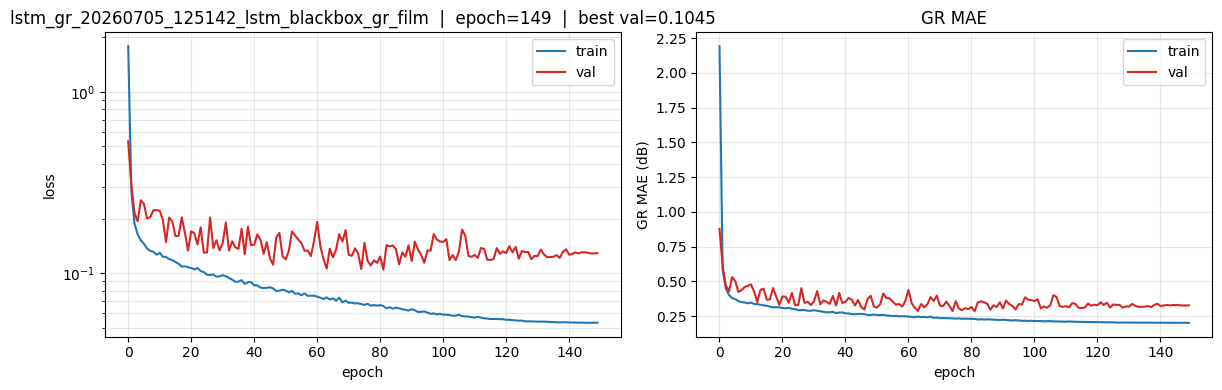

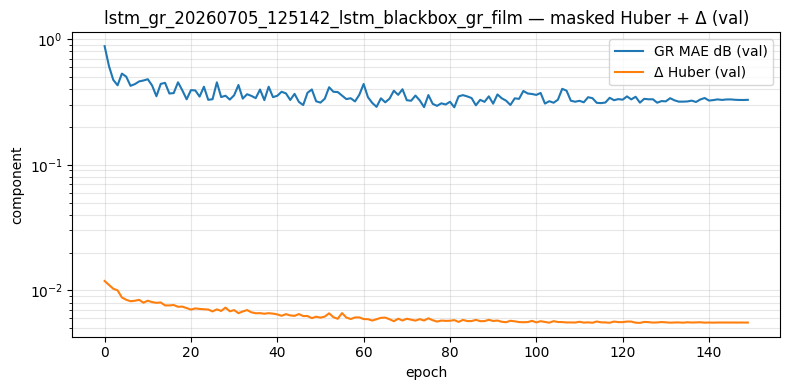

In [5]:
# ── 4. Loss curves (total + MAE / Δ components) ──────────────────────

_ = plot_loss_curves(RUN_DIR)

csv_path = Path(RUN_DIR) / "csv" / "metrics.csv"
if csv_path.exists():
    _df = pd.read_csv(csv_path)
    comp_cols = [
        ("mae_db/val", "GR MAE dB (val)"),
        ("delta_db/val", "Δ Huber (val)"),
    ]
    if any(c in _df.columns for c, _ in comp_cols):
        fig, ax = plt.subplots(figsize=(8, 4))
        for col, label in comp_cols:
            if col in _df.columns:
                rows = _df.dropna(subset=[col])[["epoch", col]]
                if len(rows):
                    ax.plot(rows["epoch"], rows[col], label=label, lw=1.5)
        ax.set_xlabel("epoch")
        ax.set_ylabel("component")
        ax.set_yscale("log")
        ax.grid(alpha=0.3, which="both")
        ax.legend()
        ax.set_title(f"{RUN_NAME} — masked Huber + Δ (val)")
        plt.tight_layout()
        plt.show()

In [6]:
# ── 5. Checkpoint loading (BlackboxGRLSTM from model_blackbox_gr.py) ──

def load_model_from_ckpt(ckpt_path, hparams_path=None):
    """Build from hparams.json and load weights (strip Lightning 'model.' prefix)."""
    hparams_path = hparams_path or _find_hparams_json(ckpt_path)
    with open(hparams_path) as f:
        hp = json.load(f)
    assert hp.get("model_type") == MODEL_TYPE, hp.get("model_type")
    m = hp["model"]
    model = BlackboxGRLSTM(
        hop_size=int(hp["hop_size"]),
        sample_rate=int(hp["sample_rate"]),
        enc_channels=int(m["enc_channels"]),
        frontend_channels=int(m["frontend_channels"]),
        temporal_kernel=int(m["temporal_kernel"]),
        temporal_dilations=tuple(int(d) for d in m["temporal_dilations"]),
        hidden_size=int(m["hidden_size"]),
        film_order=int(m["film_order"]),
    )
    sd = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)["state_dict"]
    model.load_state_dict({k[len("model."):]: v for k, v in sd.items() if k.startswith("model.")})
    model.to(DEVICE).eval()
    n_params = sum(p.numel() for p in model.parameters())
    rf = model.temporal_context + 1
    print(f"Loaded {n_params:,}-param Blackbox-LSTM GR model  "
          f"(hop={model.hop_size}, enc={m['enc_channels']}ch, "
          f"temporal dilations={list(m['temporal_dilations'])}, "
          f"RF {rf} frames ~= {rf * model.hop_size / int(hp['sample_rate']):.2f} s, "
          f"FiLM order={m['film_order']})")
    return model, hp


MODEL, HP = load_model_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
RMS_WIN = int(HP.get("rms_window", RMS_WINDOW))
print(f"Reference-GR RMS window: {RMS_WIN}")


Loaded 16,249-param Blackbox-LSTM GR model  (hop=256, enc=16ch, temporal dilations=[1, 4, 16, 64], RF 256 frames ~= 1.49 s, FiLM order=3)
Reference-GR RMS window: 1024


In [7]:
# ── 6. Prediction & visualisation (stateless, conditioned) ───────────
# Single-window prediction runs a `pre_roll_sec` context in the SAME causal
# forward pass (cold start = zero frame-context = silence), then crops to
# the requested window. No module state to reset — every call is independent.
# `pair_paths` comes from the run-selection cell (── 2).

DEFAULT_PRE_ROLL_SEC = 10.0


@torch.no_grad()
def predict_gr_curves(setting, song, start_sec=0.0, duration_sec=6.0,
                      pre_roll_sec=DEFAULT_PRE_ROLL_SEC, model=None):
    model = model or MODEL
    sr = int(HP["sample_rate"])
    dry_path, wet_path = pair_paths(setting, song)
    params = torch.tensor([normalize_setting_params(setting)], dtype=torch.float32)

    start = int(round(start_sec * sr))
    stop = start + int(round(duration_sec * sr))
    context_start = max(0, start - int(round(pre_roll_sec * sr)))
    offset = start - context_start

    dry, wet = _read_dry_wet_segment(dry_path, wet_path, context_start, stop, sr)
    L = dry.shape[-1] - (dry.shape[-1] % model.hop_size)   # whole frames only
    dry, wet = dry[..., :L], wet[..., :L]
    gr_target_db = gain_reduction_db(
        dry.unsqueeze(0), wet.unsqueeze(0), RMS_WIN
    ).squeeze(0).clamp(GR_DB_MIN, GR_DB_MAX)

    gr = model(dry.unsqueeze(0).to(DEVICE), params.to(DEVICE))
    gr_pred_db = model.to_db(gr, sample_len=L).squeeze(0)

    n = min(stop - start, L - offset)
    w = slice(offset, offset + n)
    gr_true = gr_target_db[..., w].squeeze().cpu().numpy()
    gr_pred = gr_pred_db[..., w].squeeze().cpu().numpy()
    err = gr_pred - gr_true

    return {
        "song": song, "setting": setting, "params": params.squeeze(0).tolist(),
        "sample_rate": sr, "start_sec": start_sec, "duration_sec": n / sr,
        "pre_roll_sec": offset / sr, "time": np.arange(n) / sr,
        "dry": dry[..., w].squeeze().cpu().numpy(),
        "gr_true": gr_true, "gr_pred": gr_pred, "error": err,
        "mae_db": float(np.mean(np.abs(err))),
        "rmse_db": float(np.sqrt(np.mean(err ** 2))),
    }


def visualize_prediction(setting=None, song=None, start_sec=30.0, duration_sec=6.0,
                         pre_roll_sec=DEFAULT_PRE_ROLL_SEC, title=None):
    assert (song and setting) or TEST_PAIRS, "No local test pairs — pass song= and setting="
    song = song or TEST_PAIRS[0][0]
    setting = setting or TEST_PAIRS[0][1]
    curves = predict_gr_curves(setting, song, start_sec, duration_sec, pre_roll_sec)

    t = curves["time"]
    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True,
                             gridspec_kw={"height_ratios": [1, 2, 1]})

    axes[0].plot(t, curves["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry"); axes[0].set_ylim(-1.05, 1.05); axes[0].grid(alpha=0.3)

    axes[1].plot(t, curves["gr_true"], label="target", lw=1.4, color="#1f77b4")
    axes[1].plot(t, curves["gr_pred"], label="prediction", lw=1.2, color="#d62728", alpha=0.85)
    axes[1].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[1].set_ylabel("GR (dB)"); axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.3)

    axes[2].plot(t, curves["error"], lw=0.8, color="#2ca02c")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("error (dB)"); axes[2].grid(alpha=0.3)
    axes[2].set_xlabel("time (s)")

    p = ", ".join(f"{v:.2f}" for v in curves["params"])
    fig.suptitle(title or (
        f"{curves['song']}  |  {curves['setting']}\n"
        f"params=[{p}]  pre-roll={curves['pre_roll_sec']:.1f}s  "
        f"MAE={curves['mae_db']:.2f} dB  RMSE={curves['rmse_db']:.2f} dB"
    ), fontsize=10)
    plt.tight_layout(); plt.show()
    return curves


def conditioning_sweep(song=None, settings=None, start_sec=30.0, duration_sec=6.0,
                       pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    """Same song through every setting — does the model follow the knobs?

    Defaults to SWEEP_SONG (first manifest song fully synced locally) and
    skips settings whose dry/wet exports are missing on this machine.
    """
    song = song or SWEEP_SONG
    settings = settings or SPLIT.all_settings
    have = [s for s in settings if all(os.path.isfile(p) for p in pair_paths(s, song))]
    if len(have) < len(settings):
        print(f"[warning] {song}: {len(settings) - len(have)} settings missing locally — skipped")
    assert have, f"No settings with local dry/wet for {song}"
    curves = [predict_gr_curves(s, song, start_sec, duration_sec, pre_roll_sec)
              for s in have]

    fig, axes = plt.subplots(len(curves), 1, figsize=(11, 1.8 * len(curves)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, c in zip(axes[:, 0], curves):
        ax.plot(c["time"], c["gr_true"], lw=1.1, color="#1f77b4", label="target")
        ax.plot(c["time"], c["gr_pred"], lw=0.9, color="#d62728", alpha=0.85, label="prediction")
        ax.axhline(0, color="k", lw=0.5, alpha=0.4)
        ax.set_ylabel("GR (dB)", fontsize=8)
        ax.set_title(f"{c['setting']}  -  MAE {c['mae_db']:.2f} dB", fontsize=8, loc="left")
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc="lower right", fontsize=8)
    axes[-1, 0].set_xlabel("time (s)")
    fig.suptitle(f"Conditioning sweep - {song} ({duration_sec:.0f}s @ {start_sec:.0f}s)",
                 fontsize=11)
    plt.tight_layout(); plt.show()

    df = pd.DataFrame([
        {"setting": c["setting"], "MAE (dB)": c["mae_db"], "RMSE (dB)": c["rmse_db"]}
        for c in curves
    ])
    display(df)
    return curves, df

## Usage

Re-run the cells below any time; they read the latest synced files from Drive.
Use the available-runs cell first, then set `SELECTED_RUN_NAME` in the selection cell.

- `visualize_prediction(setting=..., song=...)` — any (setting, song); defaults to the first **test_ground_truth** pair.
- `conditioning_sweep(song=...)` — one song through all training settings (defaults to the val song). The per-setting MAE table is the headline conditioning result.
- The metric cells score on the canonical **9-column engine** (`GR MAE (dB)`, `MR-STE`, `MR-STFT`, `ESR (A-wt)`, `MAE (L1)`, `MSE (L2)`, `EDC`, `M_NRMSE`, `M_SF`) ported from [`02b_sota_training/eval_lstm_diffssl_tvc.ipynb`](../02b_sota_training/eval_lstm_diffssl_tvc.ipynb) — identical to [`eval_lstm_detector_gr.ipynb`](eval_lstm_detector_gr.ipynb), so numbers are directly comparable across models. The model predicts a GR curve; wet audio is **reconstructed** as `dry * 10**(GR_dB/20)` before scoring.
  - **── 7** scores the **validation split** (held-out song × all settings — the "Valid" row of the run table).
  - **── 8** scores the held-out **TEST set** (`test_ground_truth/`, unseen songs, mostly unseen settings) — the SAME test set as the detector / gain-prior notebooks, and under the v2 split policy the ONLY test set. Cell ── 2 asserts it is disjoint from the run's train/val pairs.
  - **── 9** is the **ablation verdict**: this run's val→test GR MAE gap next to the detector twin's (requires the detector eval's ── 7/── 8 CSVs).


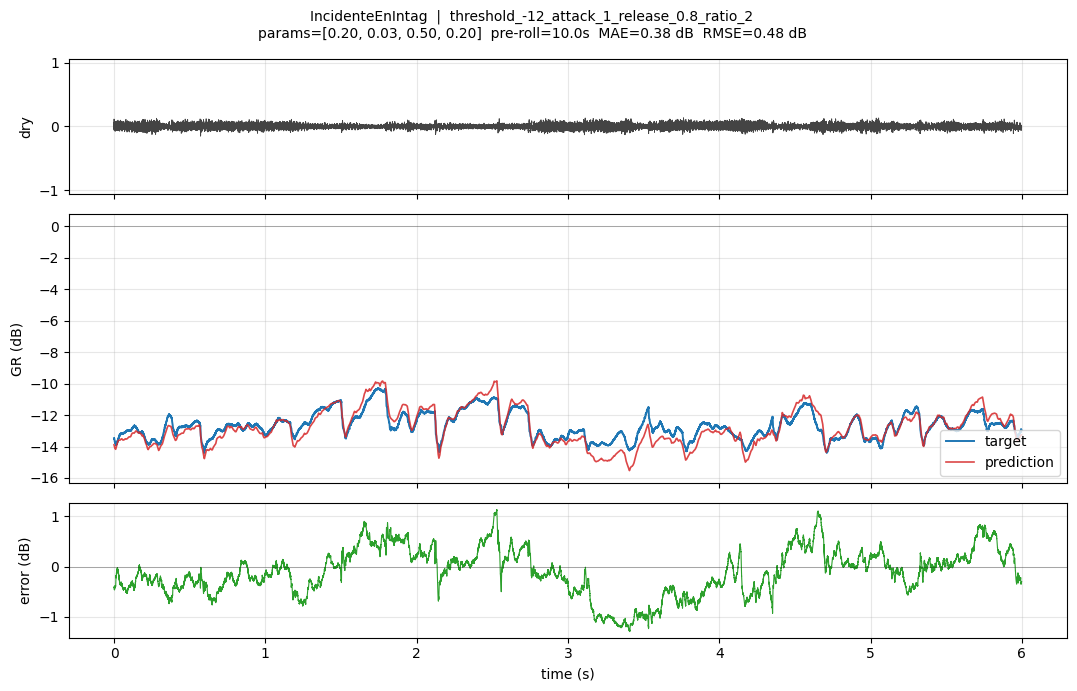

In [8]:
# Single prediction preview — held-out test_ground_truth pair
song, setting = TEST_PAIRS[0]
_ = visualize_prediction(setting=setting, song=song, start_sec=30.0, duration_sec=6.0)

[warning] AncoraQui: 5 settings missing locally — skipped


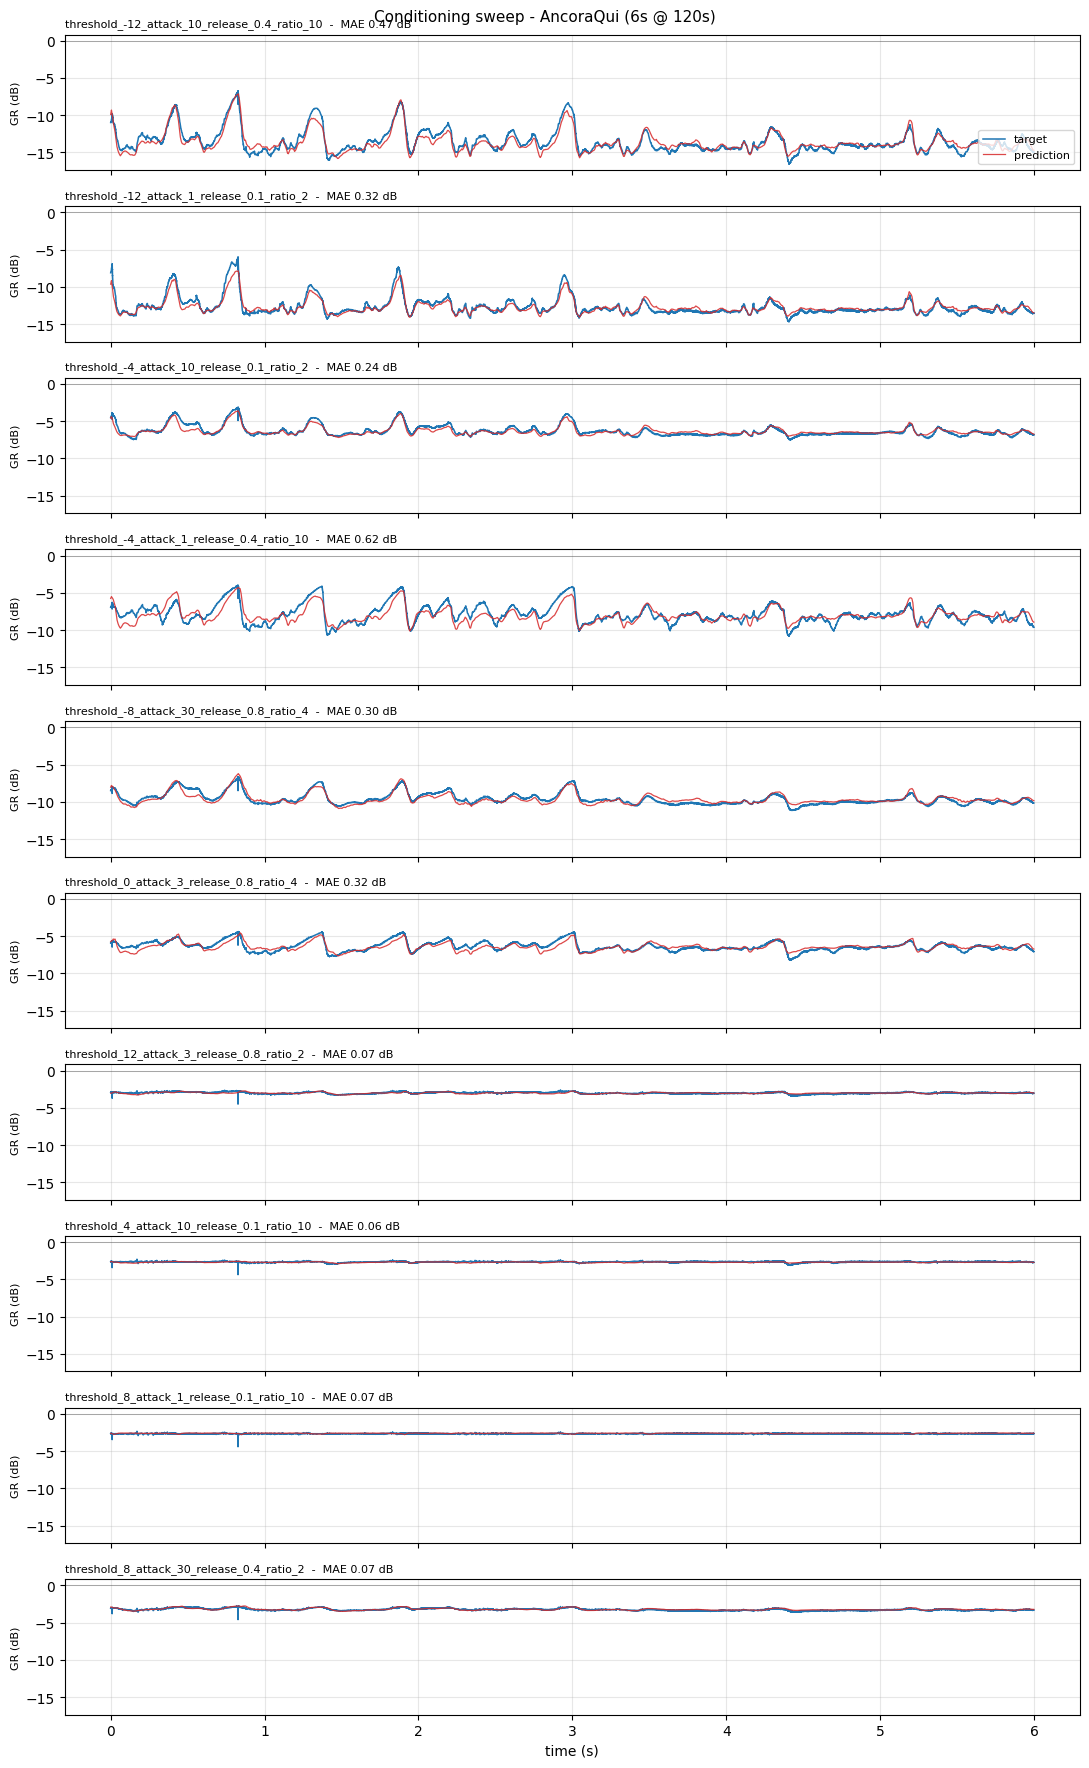

,setting,MAE (dB),RMSE (dB)
0,threshold_-12_attack_10_release_0.4_ratio_10,0.471447,0.584929
1,threshold_-12_attack_1_release_0.1_ratio_2,0.320305,0.440597
2,threshold_-4_attack_10_release_0.1_ratio_2,0.236116,0.306177
3,threshold_-4_attack_1_release_0.4_ratio_10,0.615237,0.773733
4,threshold_-8_attack_30_release_0.8_ratio_4,0.304687,0.361461
5,threshold_0_attack_3_release_0.8_ratio_4,0.320221,0.399531
6,threshold_12_attack_3_release_0.8_ratio_2,0.074811,0.099024
7,threshold_4_attack_10_release_0.1_ratio_10,0.064593,0.083646
8,threshold_8_attack_1_release_0.1_ratio_10,0.070122,0.079999
9,threshold_8_attack_30_release_0.4_ratio_2,0.069401,0.086135


In [9]:
# Conditioning sweep: validation song through all 10 settings
sweep_curves, sweep_df = conditioning_sweep(start_sec=120.0, duration_sec=6.0)

In [10]:
# ── 6b. Metric engine (ported from 02b_sota_training/eval_lstm_diffssl_tvc.ipynb) ──
#
# The canonical 9-column table so this GR model drops straight into the
# cross-model comparison (identical engine to eval_lstm_gain_prior /
# eval_lstm_condlstm_gr_bins). The model predicts a GR curve; wet audio is
# reconstructed as dry * 10**(GR_dB/20) and scored here, so GR and wet-audio
# models stay directly comparable. Every moving-average envelope uses an O(N)
# cumsum window; the FFT metrics reimplement auraloss MultiResolutionSTFTLoss
# and src.losses.{M_SF, EDC}, batched. MR-STFT / ESR verified against
# nablafx.evaluation (auraloss) to <1e-3 / <1e-4.

from scipy.signal import bilinear, lfilter

SR = int(HP["sample_rate"])
EPS = 1e-10

# Multi-resolution window / FFT sets (identical to the diffssl_tvc engine)
MR_STE_WINDOWS   = (256, 1024, 4096)                     # short-time energy (envelope shape)
MR_NRMSE_WINDOWS = (512, 1024, 2048)                     # == src.losses.multi_resolution_nrmse
STFT_SIZES       = (512, 1024, 2048)                     # spectral-flux resolutions
_MRSTFT_RES      = [(1024, 120, 600), (2048, 240, 1200), (512, 50, 240)]   # auraloss defaults

# Final metric columns: GR-stage | colour-stage | standard
METRIC_COLS = [
    "GR MAE (dB)", "MR-STE",                             # GR stage
    "MR-STFT", "ESR (A-wt)",                             # colour stage (auraloss MR-STFT + A-weighted ESR)
    "MAE (L1)", "MSE (L2)", "EDC", "M_NRMSE", "M_SF",    # standard
]


# ── moving-average envelopes (cumsum: O(N), window-independent) ──
def _moving_meansq(x_sq, W, centered):
    """Sliding mean of x**2 via prefix sums. centered=symmetric, else causal (trailing)."""
    n = x_sq.shape[-1]
    c = np.empty(n + 1); c[0] = 0.0; np.cumsum(x_sq, out=c[1:])
    i = np.arange(n)
    if centered:
        lo = i - (W // 2); hi = lo + W
    else:                                                # causal == src.dsp_torch.gain_reduction_db
        hi = i + 1; lo = hi - W
    lo = np.clip(lo, 0, n); hi = np.clip(hi, 0, n)
    return (c[hi] - c[lo]) / np.maximum(hi - lo, 1)

def _to_db(x):       return 20.0 * np.log10(np.maximum(x, EPS))
def _esr(pred, tgt): return float(np.sum((tgt - pred) ** 2) / (np.sum(tgt * tgt) + 1e-8))

# A-weighting IIR (analog prototype -> bilinear) for the A-weighted ESR
def _a_weighting_ba(fs):
    f1, f2, f3, f4 = 20.598997, 107.65265, 737.86223, 12194.217
    A1000 = 1.9997
    nums = [(2 * np.pi * f4) ** 2 * 10 ** (A1000 / 20.0), 0, 0, 0, 0]
    dens = np.polymul([1, 4 * np.pi * f4, (2 * np.pi * f4) ** 2],
                      [1, 4 * np.pi * f1, (2 * np.pi * f1) ** 2])
    dens = np.polymul(np.polymul(dens, [1, 2 * np.pi * f3]), [1, 2 * np.pi * f2])
    return bilinear(nums, dens, fs)
AW_B, AW_A = _a_weighting_ba(SR)


def reference_gr_db(dry, wet, W=RMS_WIN):
    """Reference GR trajectory = causal RMS GR (matches src.dsp_torch.gain_reduction_db)."""
    return (_to_db(np.sqrt(_moving_meansq(wet * wet, W, centered=False)))
            - _to_db(np.sqrt(_moving_meansq(dry * dry, W, centered=False))))


# ── GR-stage / envelope metrics ──
def mr_ste(pred, wet, windows=MR_STE_WINDOWS):
    """Multi-resolution short-time energy distance (envelope shape; Wright & Valimaki)."""
    pe, we = pred * pred, wet * wet
    total = 0.0
    for W in windows:
        ep = _moving_meansq(pe, W, centered=True)
        et = _moving_meansq(we, W, centered=True)
        total += np.sum(np.abs(ep - et)) / (np.sum(np.abs(et)) + 1e-8)
    return float(total / len(windows))

def mr_nrmse(pred, wet, windows=MR_NRMSE_WINDOWS):
    """Mean normalised RMS-envelope error (== src.losses.multi_resolution_nrmse, cumsum-fast)."""
    total = 0.0
    for W in windows:
        rp = np.sqrt(_moving_meansq(pred * pred, W, centered=False))
        rt = np.sqrt(_moving_meansq(wet * wet, W, centered=False))
        total += np.sqrt(np.mean((rt - rp) ** 2)) / (np.sqrt(np.mean(rt * rt)) + 1e-8)
    return float(total / len(windows))


# ── colour-stage + standard FFT metrics ──
_HANN = {}
def _win(n):
    if n not in _HANN:
        _HANN[n] = torch.hann_window(n)
    return _HANN[n]

def _stft_mag_pow(x2d, n_fft, hop, win):
    """auraloss-style magnitude = sqrt(clamp(re^2 + im^2, 1e-8))."""
    st = torch.stft(x2d, n_fft=n_fft, hop_length=hop, win_length=win,
                    window=_win(win), return_complex=True)
    return torch.sqrt(torch.clamp(st.real ** 2 + st.imag ** 2, min=1e-8))

def _stft_mag_fft(x2d, n_fft):
    """src.losses-style magnitude (hop = n_fft // 4, hann(n_fft))."""
    return torch.stft(x2d, n_fft=n_fft, hop_length=n_fft // 4,
                      window=_win(n_fft), return_complex=True).abs()

@torch.no_grad()
def fft_metrics(pred1d: torch.Tensor, wet1d: torch.Tensor) -> dict:
    """auraloss MR-STFT + src.losses {M_SF, EDC} for one (pred, wet) pair."""
    P1, T1 = pred1d.unsqueeze(0), wet1d.unsqueeze(0)
    out = {}

    # MR-STFT (auraloss default = spectral-convergence + log-magnitude, mean over 3 resolutions)
    acc = 0.0
    for n_fft, hop, win in _MRSTFT_RES:
        P = _stft_mag_pow(P1, n_fft, hop, win)[0]
        T = _stft_mag_pow(T1, n_fft, hop, win)[0]
        sc = torch.linalg.norm(T - P) / torch.linalg.norm(T)
        lm = (torch.log(P) - torch.log(T)).abs().mean()
        acc += float(sc + lm)
    out["MR-STFT"] = acc / len(_MRSTFT_RES)

    # spectral-flux (M_SF) over (512, 1024, 2048)
    sf = 0.0
    for n_fft in STFT_SIZES:
        P = _stft_mag_fft(P1, n_fft)[0]
        T = _stft_mag_fft(T1, n_fft)[0]
        pf, tf = torch.diff(P, dim=-1), torch.diff(T, dim=-1)
        sf += float((tf - pf).abs().mean() / (tf.abs().mean() + 1e-8))
    out["M_SF"] = sf / len(STFT_SIZES)

    # EDC (energy-decay-curve error, dB)
    pe = torch.flip(torch.cumsum(torch.flip(P1 ** 2, dims=(-1,)), dim=-1), dims=(-1,))
    te = torch.flip(torch.cumsum(torch.flip(T1 ** 2, dims=(-1,)), dim=-1), dims=(-1,))
    pe = pe / (pe[..., :1] + 1e-8); te = te / (te[..., :1] + 1e-8)
    out["EDC"] = float((10 * torch.log10(te.clamp(min=1e-8))
                        - 10 * torch.log10(pe.clamp(min=1e-8))).abs().mean())
    return out


def chunk_metrics(dry: np.ndarray, pred: np.ndarray, wet: np.ndarray) -> dict:
    """The 9 metric columns for one (dry, pred, wet) chunk (float64 1-D arrays).

    GR MAE compares the prediction's causal-RMS GR against the reference RMS
    GR(dry, wet), both clamped to [GR_DB_MIN, GR_DB_MAX]. FFT metrics run in float32.
    """
    gr_tgt  = np.clip(reference_gr_db(dry, wet),  GR_DB_MIN, GR_DB_MAX)
    gr_pred = np.clip(reference_gr_db(dry, pred), GR_DB_MIN, GR_DB_MAX)
    row = {
        "GR MAE (dB)": float(np.mean(np.abs(gr_pred - gr_tgt))),
        "MR-STE":      mr_ste(pred, wet),
        "ESR (A-wt)":  _esr(lfilter(AW_B, AW_A, pred), lfilter(AW_B, AW_A, wet)),
        "MAE (L1)":    float(np.mean(np.abs(pred - wet))),
        "MSE (L2)":    float(np.mean((pred - wet) ** 2)),
        "M_NRMSE":     mr_nrmse(pred, wet),
    }
    row.update(fft_metrics(torch.from_numpy(pred).float(),
                           torch.from_numpy(wet).float()))
    return row


# ── verify MR-STFT / ESR against nablafx.evaluation (auraloss) ──
try:
    from nablafx.evaluation import get_function
    _g = torch.Generator().manual_seed(0)
    _p = torch.randn(SR, generator=_g); _t = torch.randn(SR, generator=_g)
    _nab_mrstft, _nab_esr = get_function("mrstft_loss"), get_function("esr_loss")
    _pt, _tt = _p.view(1, 1, -1), _t.view(1, 1, -1)
    _fm = fft_metrics(_p, _t)
    _d_mrstft = abs(float(_nab_mrstft(_pt, _tt)) - _fm["MR-STFT"])
    _d_esr = abs(float(_nab_esr(_pt, _tt)) - _esr(_p.double().numpy(), _t.double().numpy()))
    assert _d_mrstft < 1e-3, _d_mrstft
    assert _d_esr < 1e-4, _d_esr
    print(f"nablafx.evaluation verified — MR-STFT Δ={_d_mrstft:.2e}, ESR Δ={_d_esr:.2e}")
except Exception as e:
    print(f"nablafx verification skipped: {e}")

print(f"Metric engine registered — {len(METRIC_COLS)} columns: {METRIC_COLS}")

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


nablafx.evaluation verified — MR-STFT Δ=0.00e+00, ESR Δ=5.61e-08
Metric engine registered — 9 columns: ['GR MAE (dB)', 'MR-STE', 'MR-STFT', 'ESR (A-wt)', 'MAE (L1)', 'MSE (L2)', 'EDC', 'M_NRMSE', 'M_SF']


In [11]:
# ── 7. Audio metrics on the VALIDATION split (streaming) ─────────────
# Streams each (song, setting) pair whole-song in NON-overlapping chunks with
# the explicit (lstm_state, frame_context) carried across chunks — exact vs a
# single full forward. The model predicts a GR curve; wet audio is
# reconstructed as dry * 10**(GR_dB/20) and each chunk is scored with the
# ported metric engine (chunk_metrics) — the SAME 9-column table as
# eval_lstm_gain_prior / eval_lstm_diffssl_tvc, results duration-weighted.
# Under the v2 split policy the manifest test == the external
# test_ground_truth set, which is scored once in ── 8 — this cell covers the
# validation split only (val song × all settings). Pairs missing locally
# were already dropped in ── 2 (with warnings).

MAX_EVAL_PAIRS: int | None = None    # small int for a smoke test
STREAM_CHUNK_SEC = 10.0
SAVE_CHUNK_METRICS = False
MIN_METRIC_FRAMES = max(STFT_SIZES)  # skip sub-FFT tail chunks (torch.stft needs >= n_fft)

sr = SR
step = MODEL.hop_size
chunk_frames = max(step, (int(round(STREAM_CHUNK_SEC * sr)) // step) * step)


@torch.no_grad()
def stream_pair_metrics(song: str, setting: str, paths_fn=pair_paths) -> list[dict]:
    """Streaming pass over a whole (song, setting) pair; per-chunk metric rows."""
    dry_path, wet_path = paths_fn(setting, song)
    params = torch.tensor([normalize_setting_params(setting)], dtype=torch.float32).to(DEVICE)
    total = _pair_num_frames(dry_path, wet_path, sr)
    state, rows = None, []
    for ci, o in enumerate(range(0, total, chunk_frames), start=1):
        dry, wet = _read_dry_wet_segment(dry_path, wet_path, o, min(o + chunk_frames, total), sr)
        L = dry.shape[-1] - (dry.shape[-1] % step)
        if L < step:
            break
        dry, wet = dry[..., :L], wet[..., :L]
        gr, state = MODEL(dry.unsqueeze(0).to(DEVICE), params, state, return_state=True)
        gr_db = MODEL.to_db(gr, sample_len=L).squeeze(0).cpu()
        pred_wet = dry * _db_to_amplitude(gr_db)        # reconstruct wet from predicted GR
        if L < MIN_METRIC_FRAMES:                       # too short for the largest STFT
            continue
        # float64 1-D arrays for the ported metric engine (FFT metrics run in float32).
        d = dry.squeeze(0).double().cpu().numpy()
        w = wet.squeeze(0).double().cpu().numpy()
        p = pred_wet.squeeze(0).double().cpu().numpy()
        rows.append({"Chunk": ci, "Start (s)": o / sr, "Duration (s)": L / sr, "Frames": L,
                     **chunk_metrics(d, p, w)})
    return rows


val_pair_metrics_df = pd.DataFrame()
audio_metrics_df = pd.DataFrame()
_pairs = VAL_PAIRS if MAX_EVAL_PAIRS is None else VAL_PAIRS[:MAX_EVAL_PAIRS]
if not _pairs:
    print("[skip] validation: no locally-available pairs "
          "(see the ── 2 warnings; sync the Drive exports to score this split)")
else:
    chunk_rows, pair_rows = [], []
    for i, (song, setting) in enumerate(_pairs, start=1):
        print(f"[validation {i}/{len(_pairs)}] {song} / {setting}")
        rows = stream_pair_metrics(song, setting)
        chunk_rows += [{"Song": song, "Setting": setting, **r} for r in rows]
        pair_rows.append({
            "Split": "validation", "Song": song, "Setting": setting,
            "Duration (s)": sum(r["Frames"] for r in rows) / sr,
            **_weighted_average_metric_rows(rows, METRIC_COLS),
        })
        gc.collect()

    total_frames = sum(r["Frames"] for r in chunk_rows)
    split_row = {
        "Split": "validation", "Pairs": len(_pairs), "Chunks": len(chunk_rows),
        "Duration (s)": total_frames / sr,
        **_weighted_average_metric_rows(chunk_rows, METRIC_COLS),
    }

    val_pair_metrics_df = pd.DataFrame(pair_rows)
    audio_metrics_df = pd.DataFrame([split_row])
    val_pair_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_validation_pairs.csv", index=False)
    audio_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_validation.csv", index=False)
    if SAVE_CHUNK_METRICS:
        pd.DataFrame(chunk_rows).to_csv(
            Path(RUN_DIR) / "eval_audio_metrics_validation_chunks.csv", index=False)
    print(f"Saved -> {RUN_DIR}/eval_audio_metrics_validation(.csv, _pairs.csv)")

    display(val_pair_metrics_df)
    display(audio_metrics_df)

[validation 1/10] AncoraQui / threshold_-12_attack_10_release_0.4_ratio_10
[validation 2/10] AncoraQui / threshold_-12_attack_1_release_0.1_ratio_2
[validation 3/10] AncoraQui / threshold_-4_attack_10_release_0.1_ratio_2
[validation 4/10] AncoraQui / threshold_-4_attack_1_release_0.4_ratio_10
[validation 5/10] AncoraQui / threshold_-8_attack_30_release_0.8_ratio_4
[validation 6/10] AncoraQui / threshold_0_attack_3_release_0.8_ratio_4
[validation 7/10] AncoraQui / threshold_12_attack_3_release_0.8_ratio_2
[validation 8/10] AncoraQui / threshold_4_attack_10_release_0.1_ratio_10
[validation 9/10] AncoraQui / threshold_8_attack_1_release_0.1_ratio_10
[validation 10/10] AncoraQui / threshold_8_attack_30_release_0.4_ratio_2
Saved -> /Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs/lstm_gr_20260705_125142_lstm_blackbox_gr_film/eval_audio_metrics_validation(.csv, _pairs.csv)


,Split,Song,Setting,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,validation,AncoraQui,threshold_-12_attack_10_release_0.4_ratio_10,233.453424,0.710826,0.162765,0.208897,0.118107,0.001213,0.000004,0.352146,0.107873,0.139853
1,validation,AncoraQui,threshold_-12_attack_1_release_0.1_ratio_2,233.453424,0.627813,0.117694,0.182911,0.108199,0.001233,0.000004,0.299614,0.080148,0.140186
2,validation,AncoraQui,threshold_-4_attack_10_release_0.1_ratio_2,233.453424,0.303300,0.056278,0.096867,0.095134,0.002293,0.000017,0.244258,0.035404,0.058861
3,validation,AncoraQui,threshold_-4_attack_1_release_0.4_ratio_10,233.453424,0.766476,0.179908,0.227749,0.116725,0.002370,0.000016,0.354512,0.118189,0.142786
4,validation,AncoraQui,threshold_-8_attack_30_release_0.8_ratio_4,233.453424,0.423219,0.088274,0.121739,0.100456,0.001650,0.000009,0.285361,0.056092,0.069646
5,validation,AncoraQui,threshold_0_attack_3_release_0.8_ratio_4,233.453424,0.467483,0.101134,0.137441,0.100397,0.002399,0.000018,0.288141,0.064845,0.076818
6,validation,AncoraQui,threshold_12_attack_3_release_0.8_ratio_2,233.453424,0.154335,0.024719,0.065899,0.092841,0.003176,0.000033,0.206170,0.014389,0.030913
7,validation,AncoraQui,threshold_4_attack_10_release_0.1_ratio_10,233.453424,0.134869,0.023333,0.065000,0.092409,0.003294,0.000036,0.201082,0.013678,0.030559
8,validation,AncoraQui,threshold_8_attack_1_release_0.1_ratio_10,233.453424,0.115234,0.018102,0.060158,0.092299,0.003299,0.000036,0.194384,0.009162,0.027208
9,validation,AncoraQui,threshold_8_attack_30_release_0.4_ratio_2,233.453424,0.128261,0.021741,0.062932,0.093092,0.003109,0.000032,0.200213,0.012526,0.029804


,Split,Pairs,Chunks,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,validation,10,240,2334.53424,0.383181,0.079395,0.122959,0.100966,0.002404,0.00002,0.262588,0.051231,0.074663


## Held-out TEST set (`test_ground_truth`)

Final generalisation check on the **held-out test set** in
`Diff-SSL-G-Comp/test_ground_truth/` — under the v2 split policy this folder is
the **only** test set: its `(song, setting)` pairs are excluded from train/val
**by pair key** at split-build time, and cell ── 2 re-asserts disjointness
against the loaded manifest before anything is scored (the v1 run
`lstm_gr_20260702_174039` failed exactly this check: 4 test pairs in train,
1 in val, making its 0.268 dB "test" MAE invalid).

This is the same held-out test set used by
[`eval_lstm_gain_prior.ipynb`](../06_output/eval_lstm_gain_prior.ipynb), scored
with the **exact same** streaming and canonical 9-column engine as ── 7 — so the
numbers are directly comparable across models.

The blackbox model predicts the GR curve from dry audio + knobs, so no
`gr_curves/*.pt` export is required — the target GR is recovered from
`(dry, wet)` inside `chunk_metrics`. Results are written to
`eval_audio_metrics_test(.csv, _pairs.csv)` alongside the validation CSVs.

In [12]:
# ── 8. Audio metrics on the held-out TEST set (test_ground_truth) ────
# Same streaming and 9-column engine as ── 7. TEST_PAIRS was discovered in
# ── 2 from the test_ground_truth/ folder and asserted disjoint from the
# run's train/val pairs; pair_paths resolves the wet files there.

print(f"Held-out test pairs (test_ground_truth): {len(TEST_PAIRS)}")

test_chunk_rows, test_pair_rows = [], []
for i, (song, setting) in enumerate(TEST_PAIRS, start=1):
    print(f"[test {i}/{len(TEST_PAIRS)}] {song} / {setting}")
    rows = stream_pair_metrics(song, setting)
    test_chunk_rows += [{"Song": song, "Setting": setting, **r} for r in rows]
    test_pair_rows.append({
        "Split": "test_ground_truth", "Song": song, "Setting": setting,
        "Duration (s)": sum(r["Frames"] for r in rows) / sr,
        **_weighted_average_metric_rows(rows, METRIC_COLS),
    })
    gc.collect()

test_total_frames = sum(r["Frames"] for r in test_chunk_rows)
test_split_row = {
    "Split": "test_ground_truth", "Pairs": len(TEST_PAIRS), "Chunks": len(test_chunk_rows),
    "Duration (s)": test_total_frames / sr,
    **_weighted_average_metric_rows(test_chunk_rows, METRIC_COLS),
}

test_pair_metrics_df = pd.DataFrame(test_pair_rows)
test_audio_metrics_df = pd.DataFrame([test_split_row])
test_pair_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_test_pairs.csv", index=False)
test_audio_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_test.csv", index=False)
if SAVE_CHUNK_METRICS:
    pd.DataFrame(test_chunk_rows).to_csv(
        Path(RUN_DIR) / "eval_audio_metrics_test_chunks.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics_test(.csv, _pairs.csv)")

display(test_pair_metrics_df)
display(test_audio_metrics_df)

Held-out test pairs (test_ground_truth): 5
[test 1/5] IncidenteEnIntag / threshold_-12_attack_1_release_0.8_ratio_2
[test 2/5] OralHygiene / threshold_-8_attack_3_release_0.4_ratio_4
[test 3/5] 54 / threshold_12_attack_1_release_0.1_ratio_2
[test 4/5] SuchFinePeople / threshold_4_attack_1_release_0.8_ratio_10
[test 5/5] Convertible / threshold_4_attack_30_release_0.8_ratio_10
Saved -> /Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs/lstm_gr_20260705_125142_lstm_blackbox_gr_film/eval_audio_metrics_test(.csv, _pairs.csv)


,Split,Song,Setting,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,test_ground_truth,IncidenteEnIntag,threshold_-12_attack_1_release_0.8_ratio_2,183.199637,0.658475,0.136117,0.163949,0.036172,0.000689,9.362120e-07,0.157369,0.084479,0.098212
1,test_ground_truth,OralHygiene,threshold_-8_attack_3_release_0.4_ratio_4,203.499683,0.752448,0.340470,0.346314,0.095040,0.001393,6.065266e-06,0.252297,0.208622,0.122851
2,test_ground_truth,54,threshold_12_attack_1_release_0.1_ratio_2,248.558005,0.080011,0.013957,0.064688,0.028954,0.001860,7.550792e-06,0.049035,0.008034,0.024501
3,test_ground_truth,SuchFinePeople,threshold_4_attack_1_release_0.8_ratio_10,220.241270,0.267513,0.062460,0.083463,0.047151,0.002361,1.157472e-05,0.071029,0.038545,0.042789
4,test_ground_truth,Convertible,threshold_4_attack_30_release_0.8_ratio_10,204.916100,0.141900,0.037480,0.133993,0.048799,0.002410,1.250805e-05,0.037459,0.023723,0.051160


,Split,Pairs,Chunks,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,test_ground_truth,5,109,1060.414694,0.359895,0.112341,0.153174,0.050498,0.001778,0.000008,0.109089,0.069104,0.065059


In [13]:
# ── 9. Ablation verdict — val→test GR MAE gap vs the detector twin ───
# The single number this ablation exists to produce. The blackbox frontend is
# timbre-CAPABLE: if song identity leaks into its GR estimate, its GR MAE
# degrades from the validation split (unseen song, seen settings) to
# test_ground_truth (unseen songs AND settings) more than the timbre-blind
# detector bank's does. Reads the split CSVs written by ── 7 / ── 8; the
# detector row uses the most recent detector_gr_lstm_film run that has them
# (run eval_lstm_detector_gr.ipynb ── 7/── 8 first to populate it).

def _split_gr_mae(run_dir) -> dict:
    out = {}
    for col, fn in (("val GR MAE (dB)", "eval_audio_metrics_validation.csv"),
                    ("test GR MAE (dB)", "eval_audio_metrics_test.csv")):
        p = Path(run_dir) / fn
        if p.is_file():
            out[col] = float(pd.read_csv(p)["GR MAE (dB)"].iloc[0])
    return out


rows = [{"model": "blackbox (learned frontend)", "run": RUN_NAME,
         **_split_gr_mae(RUN_DIR)}]

_det_runs = runs_df[runs_df["type"] == "detector_gr_lstm_film"]
for _, r in _det_runs.iloc[::-1].iterrows():     # newest scored run wins
    m = _split_gr_mae(os.path.join(RUNS_DIR, r["run"]))
    if len(m) == 2:
        rows.append({"model": "detector (fixed frontend)", "run": r["run"], **m})
        break
else:
    print("[note] no detector twin run with eval CSVs found — run "
          "eval_lstm_detector_gr.ipynb (── 7 and ── 8) to add the comparison row.")

gap_df = pd.DataFrame(rows)
if {"val GR MAE (dB)", "test GR MAE (dB)"} <= set(gap_df.columns):
    gap_df["gap (dB)"] = gap_df["test GR MAE (dB)"] - gap_df["val GR MAE (dB)"]
gap_df.to_csv(Path(RUN_DIR) / "eval_ablation_gap.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_ablation_gap.csv")
display(gap_df)

if len(gap_df) == 2 and "gap (dB)" in gap_df.columns:
    bb, det = gap_df.iloc[0], gap_df.iloc[1]
    print(f"blackbox val->test gap: {bb['gap (dB)']:+.3f} dB   "
          f"detector val->test gap: {det['gap (dB)']:+.3f} dB   "
          f"(bins predecessor: +0.287 dB, 0.267 -> 0.554)")


Saved -> /Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs/lstm_gr_20260705_125142_lstm_blackbox_gr_film/eval_ablation_gap.csv


,model,run,val GR MAE (dB),test GR MAE (dB),gap (dB)
0,blackbox (learned frontend),lstm_gr_20260705_125142_lstm_blackbox_gr_film,0.383181,0.359895,-0.023287
1,detector (fixed frontend),lstm_gr_20260704_132800_lstm_detector_gr_film,0.391858,0.418822,0.026964


blackbox val->test gap: -0.023 dB   detector val->test gap: +0.027 dB   (bins predecessor: +0.287 dB, 0.267 -> 0.554)
